# Disorder Robustness of Edge LDOS Enhancement

Runs statistical disorder averaging over 100 realizations per disorder strength.
Reports mean ± std of the enhancement factor and box-plot distributions.


In [1]:
import sys
sys.path.insert(0, "..")   # find src/nh_topo from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo.config import load_all, get_physics_params, get_figure_dir
from pathlib import Path

cfg = load_all(config_dir="../config")
p   = get_physics_params(cfg)

# Quick confirmation
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}")
print(f"Topological: t2/t1 = {p['t2']/p['t1']:.2f} > 1 → |nu|={nt.topological_invariant(p['t1'], p['t2'])}")


t1=0.8, t2=1.2, gamma=0.3, N=20
Topological: t2/t1 = 1.50 > 1 → |nu|=1


In [2]:
H0      = nt.build_ssh(p['N'], p['t1'], p['t2'], p['gamma'])
omegas  = np.linspace(p['om_min'], p['om_max'], 400)
gap_oms = np.linspace(-p['gap_hw'], p['gap_hw'], 80)
gap_size = abs(p['t2'] - p['t1'])

print(f"Gap half-width = {gap_size/2:.3f} t1")
print(f"Disorder realizations per W: {p['n_real']}")
print(f"W values: {p['W_vals']}")
print("Running disorder sweep (may take ~30 s)...")

results = nt.run_disorder_sweep(
    H0, p['W_vals'], p['edge_site'], p['bulk_site'],
    omegas, p['eta'], gap_oms, p['n_real'], p['seed'])

for W, r in results.items():
    print(f"  W={W:.1f}: <E>={r['enh_mean']:.2f} +/- {r['enh_std']:.2f}")


Gap half-width = 0.200 t1
Disorder realizations per W: 100
W values: [0.0, 0.1, 0.2, 0.4, 0.6]
Running disorder sweep (may take ~30 s)...
  W=0.0: <E>=11.25 +/- 0.00
  W=0.1: <E>=11.19 +/- 0.05
  W=0.2: <E>=11.02 +/- 0.23
  W=0.4: <E>=10.14 +/- 1.24
  W=0.6: <E>=8.85 +/- 2.35


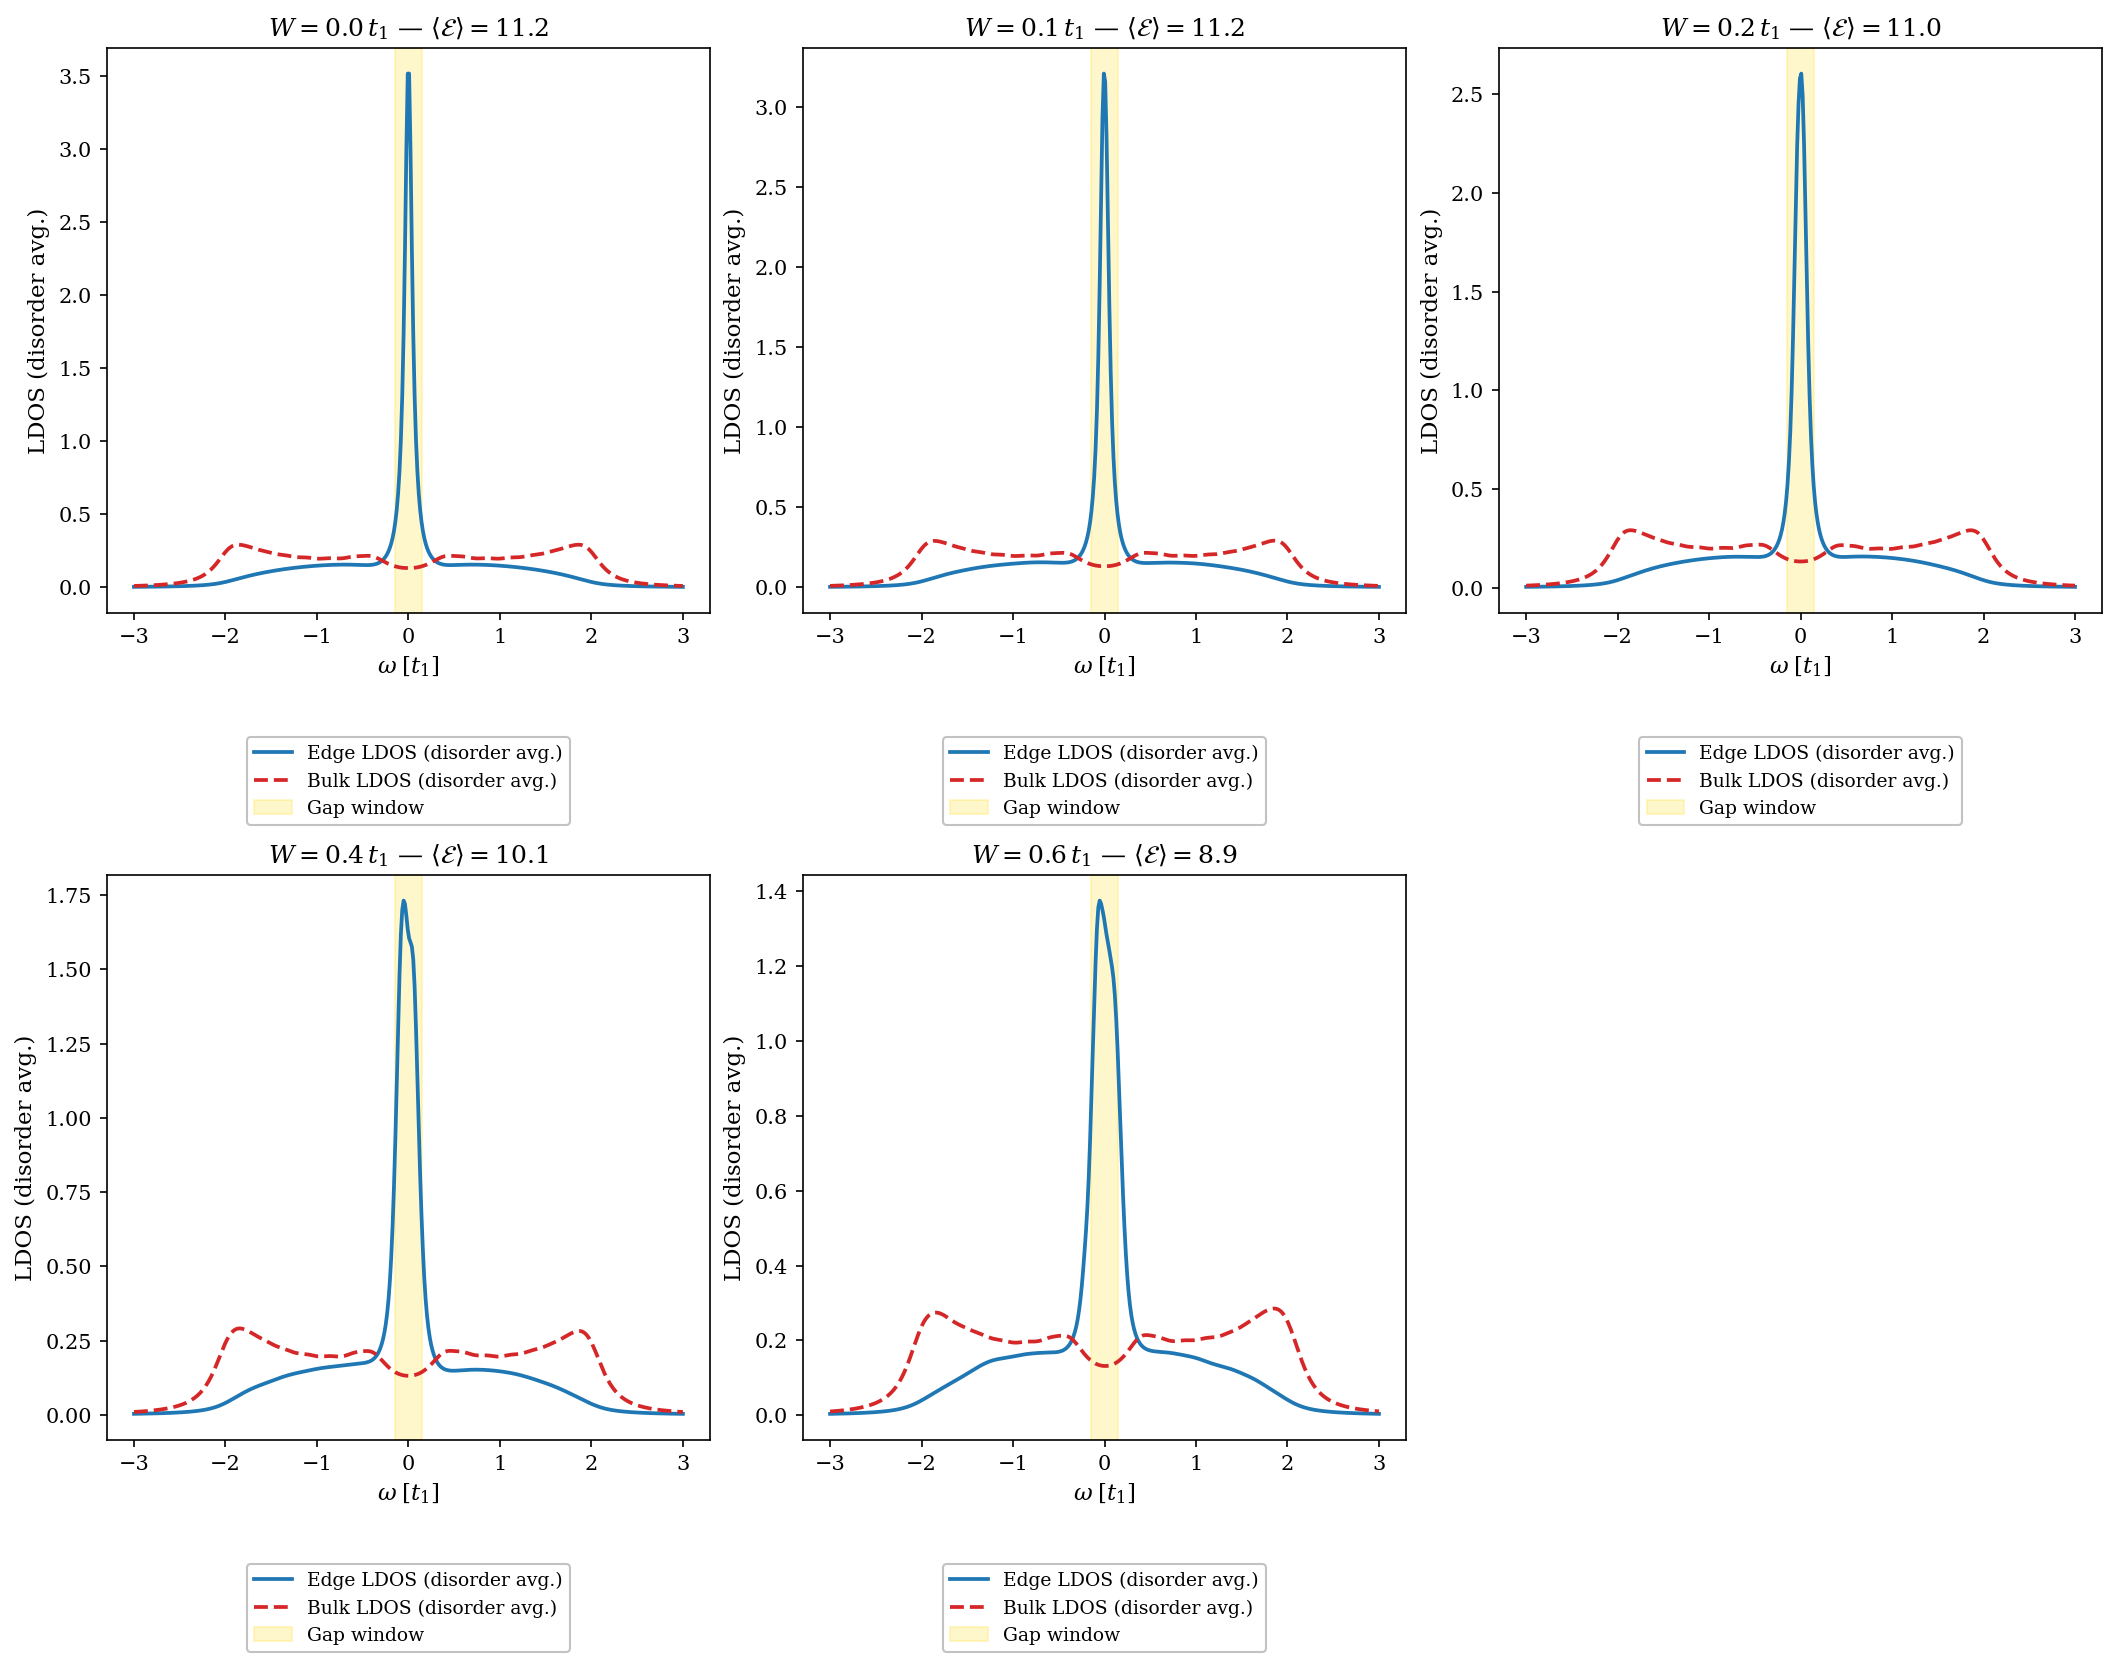

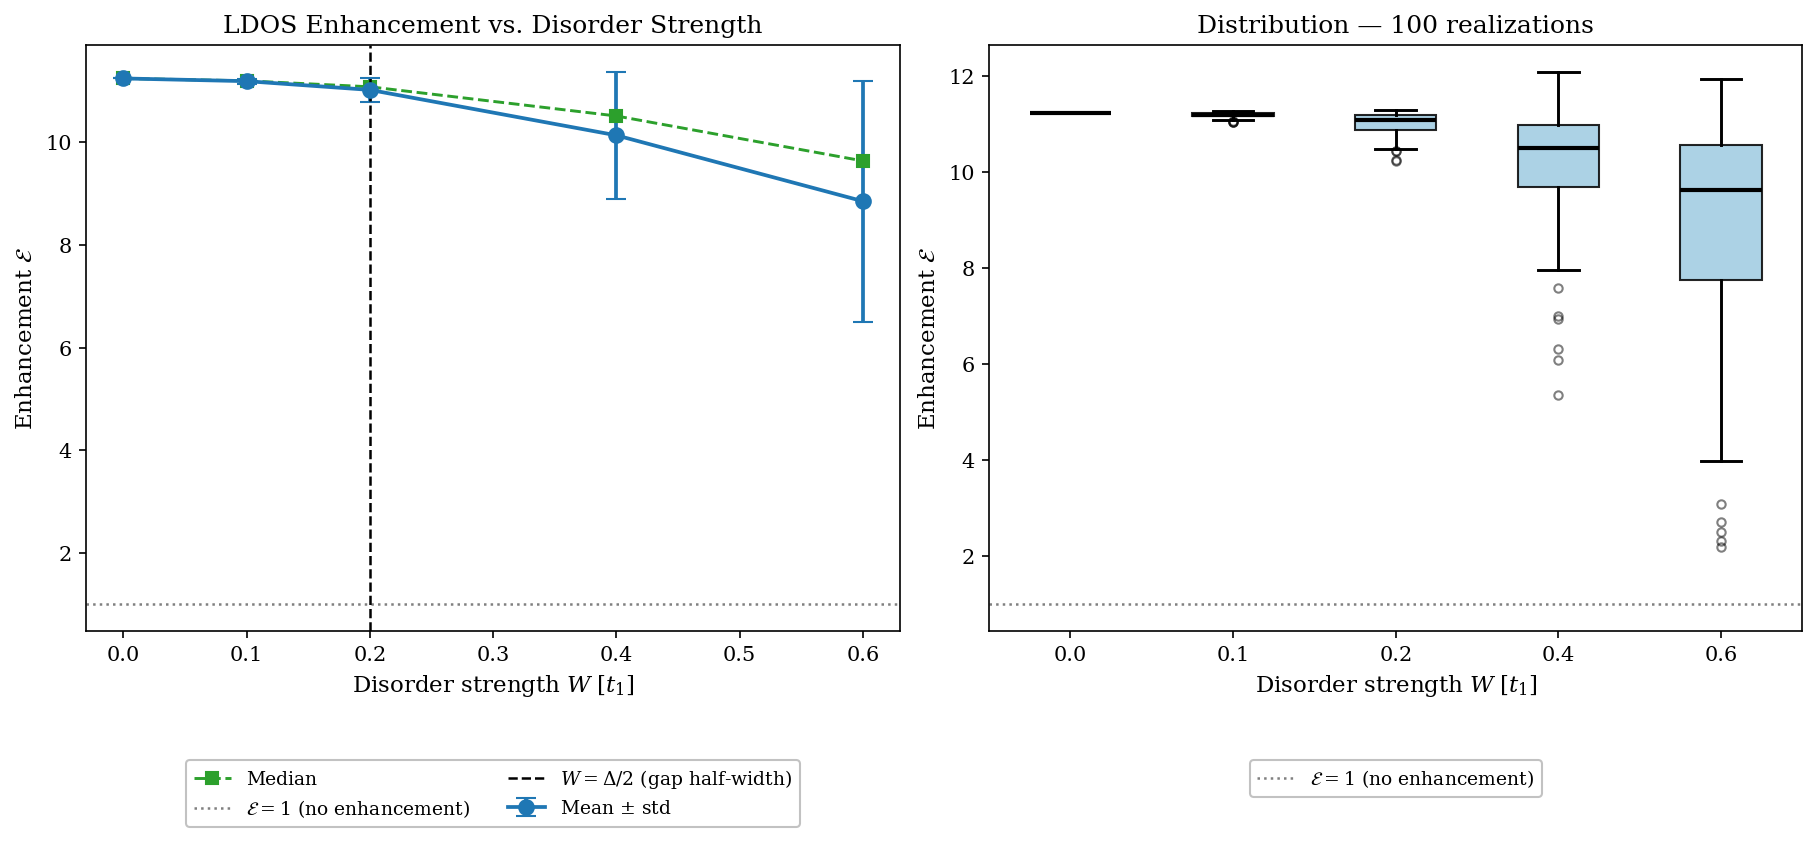

In [3]:
fig, axes = nt.plotting.plot_disorder_averaged_ldos(
    omegas, results, p['W_vals'], p['gap_hw'])
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '06_disorder_robustness_ldos'), "01_disorder_ldos")
plt.show()

fig, axes = nt.plotting.plot_enhancement_statistics(
    p['W_vals'], results, abs(p['t2'] - p['t1']))
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '06_disorder_robustness_ldos'), "02_enhancement_stats")
plt.show()
